In [3]:
import os

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


print(os.listdir("/home/reda/AQI/data"))
print("--------------------------")
print(os.listdir("/home/reda/AQI/data/raw"))


['zipped_data', 'raw', 'processed']
--------------------------
['PRSA_Tiantan.csv', 'PRSA_Gucheng.csv', 'PRSA_Wanshouxigong.csv', 'PRSA_Huairou.csv', 'PRSA_Guanyuan.csv', 'PRSA_Changping.csv', 'PRSA_Dongsi.csv', 'PRSA_Nongzhanguan.csv', 'PRSA_Aotizhongxin.csv', 'PRSA_Shunyi.csv', 'PRSA_Wanliu.csv', 'PRSA_Dingling.csv']


In [4]:
data = pd.read_csv("/home/reda/AQI/data/raw/PRSA_Aotizhongxin.csv")
data.head()


,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station
0,1,2013,3,1,0,4.0,4.0,4.0,7.0,300.0,77.0,-0.7,1023.0,-18.8,0.0,NNW,4.4,Aotizhongxin
1,2,2013,3,1,1,8.0,8.0,4.0,7.0,300.0,77.0,-1.1,1023.2,-18.2,0.0,N,4.7,Aotizhongxin
2,3,2013,3,1,2,7.0,7.0,5.0,10.0,300.0,73.0,-1.1,1023.5,-18.2,0.0,NNW,5.6,Aotizhongxin
3,4,2013,3,1,3,6.0,6.0,11.0,11.0,300.0,72.0,-1.4,1024.5,-19.4,0.0,NW,3.1,Aotizhongxin
4,5,2013,3,1,4,3.0,3.0,12.0,12.0,300.0,72.0,-2.0,1025.2,-19.5,0.0,N,2.0,Aotizhongxin


In [5]:
print(f"raw * col {data.shape}\n")
data.info()
print("\n")
data.describe()

raw * col (35064, 18)

<class 'pandas.DataFrame'>
RangeIndex: 35064 entries, 0 to 35063
Data columns (total 18 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   No       35064 non-null  int64  
 1   year     35064 non-null  int64  
 2   month    35064 non-null  int64  
 3   day      35064 non-null  int64  
 4   hour     35064 non-null  int64  
 5   PM2.5    34139 non-null  float64
 6   PM10     34346 non-null  float64
 7   SO2      34129 non-null  float64
 8   NO2      34041 non-null  float64
 9   CO       33288 non-null  float64
 10  O3       33345 non-null  float64
 11  TEMP     35044 non-null  float64
 12  PRES     35044 non-null  float64
 13  DEWP     35044 non-null  float64
 14  RAIN     35044 non-null  float64
 15  wd       34983 non-null  str    
 16  WSPM     35050 non-null  float64
 17  station  35064 non-null  str    
dtypes: float64(11), int64(5), str(2)
memory usage: 4.8 MB




,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,WSPM
count,35064.000000,35064.000000,35064.000000,35064.000000,35064.000000,34139.000000,34346.000000,34129.000000,34041.000000,33288.000000,33345.000000,35044.000000,35044.000000,35044.000000,35044.000000,35050.000000
mean,17532.500000,2014.662560,6.522930,15.729637,11.500000,82.773611,110.060391,17.375901,59.305833,1262.945145,56.353358,13.584607,1011.846920,3.123062,0.067421,1.708496
std,10122.249256,1.177213,3.448752,8.800218,6.922285,82.135694,95.223005,22.823017,37.116200,1221.436236,57.916327,11.399097,10.404047,13.688896,0.910056,1.204071
min,1.000000,2013.000000,1.000000,1.000000,0.000000,3.000000,2.000000,0.285600,2.000000,100.000000,0.214200,-16.800000,985.900000,-35.300000,0.000000,0.000000
25%,8766.750000,2014.000000,4.000000,8.000000,5.750000,22.000000,38.000000,3.000000,30.000000,500.000000,8.000000,3.100000,1003.300000,-8.100000,0.000000,0.900000
50%,17532.500000,2015.000000,7.000000,16.000000,11.500000,58.000000,87.000000,9.000000,53.000000,900.000000,42.000000,14.500000,1011.400000,3.800000,0.000000,1.400000
75%,26298.250000,2016.000000,10.000000,23.000000,17.250000,114.000000,155.000000,21.000000,82.000000,1500.000000,82.000000,23.300000,1020.100000,15.600000,0.000000,2.200000
max,35064.000000,2017.000000,12.000000,31.000000,23.000000,898.000000,984.000000,341.000000,290.000000,10000.000000,423.000000,40.500000,1042.000000,28.500000,72.500000,11.200000


In [6]:
# The datetime colum, numeric columns and Catagorical columns.
data['datetime'] = pd.to_datetime(data[['year', 'month','day','hour']])
numeric_cols = data.select_dtypes(include=['float64','int64'])
numeric_cols = [col for col in numeric_cols if col not in ['year', 'month', 'day', 'hour']]
cata_cols = data.select_dtypes(include=['str'])

       Missing Count  Percentage (%)
WSPM              14        0.039927
TEMP              20        0.057039
DEWP              20        0.057039
PRES              20        0.057039
RAIN              20        0.057039
wd                81        0.231006
PM10             718        2.047684
PM2.5            925        2.638033
SO2              935        2.666553
NO2             1023        2.917522
O3              1719        4.902464
CO              1776        5.065024


<Axes: >

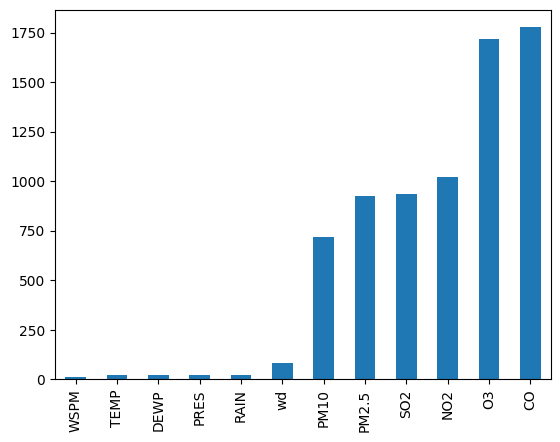

In [7]:
missing = data.isna().sum()
missing = missing[missing>0]
missing.sort_values(inplace=True)
missing_percentage = ((data.isna().sum()) / len(data)) * 100
missing_percentage = missing_percentage[missing_percentage > 0]

missing_table = pd.concat([missing, missing_percentage], axis=1)
missing_table.columns = ['Missing Count', 'Percentage (%)']

print(missing_table)
missing.plot(kind='bar')

In [8]:
skewness = data[numeric_cols].skew()
skewed_cols = skewness[skewness > 0]

print(skewed_cols)

PM2.5     1.966068
PM10      1.779569
SO2       2.801703
NO2       0.927582
CO        2.564214
O3        1.444603
PRES      0.111500
RAIN     34.719336
WSPM      1.365037
dtype: float64


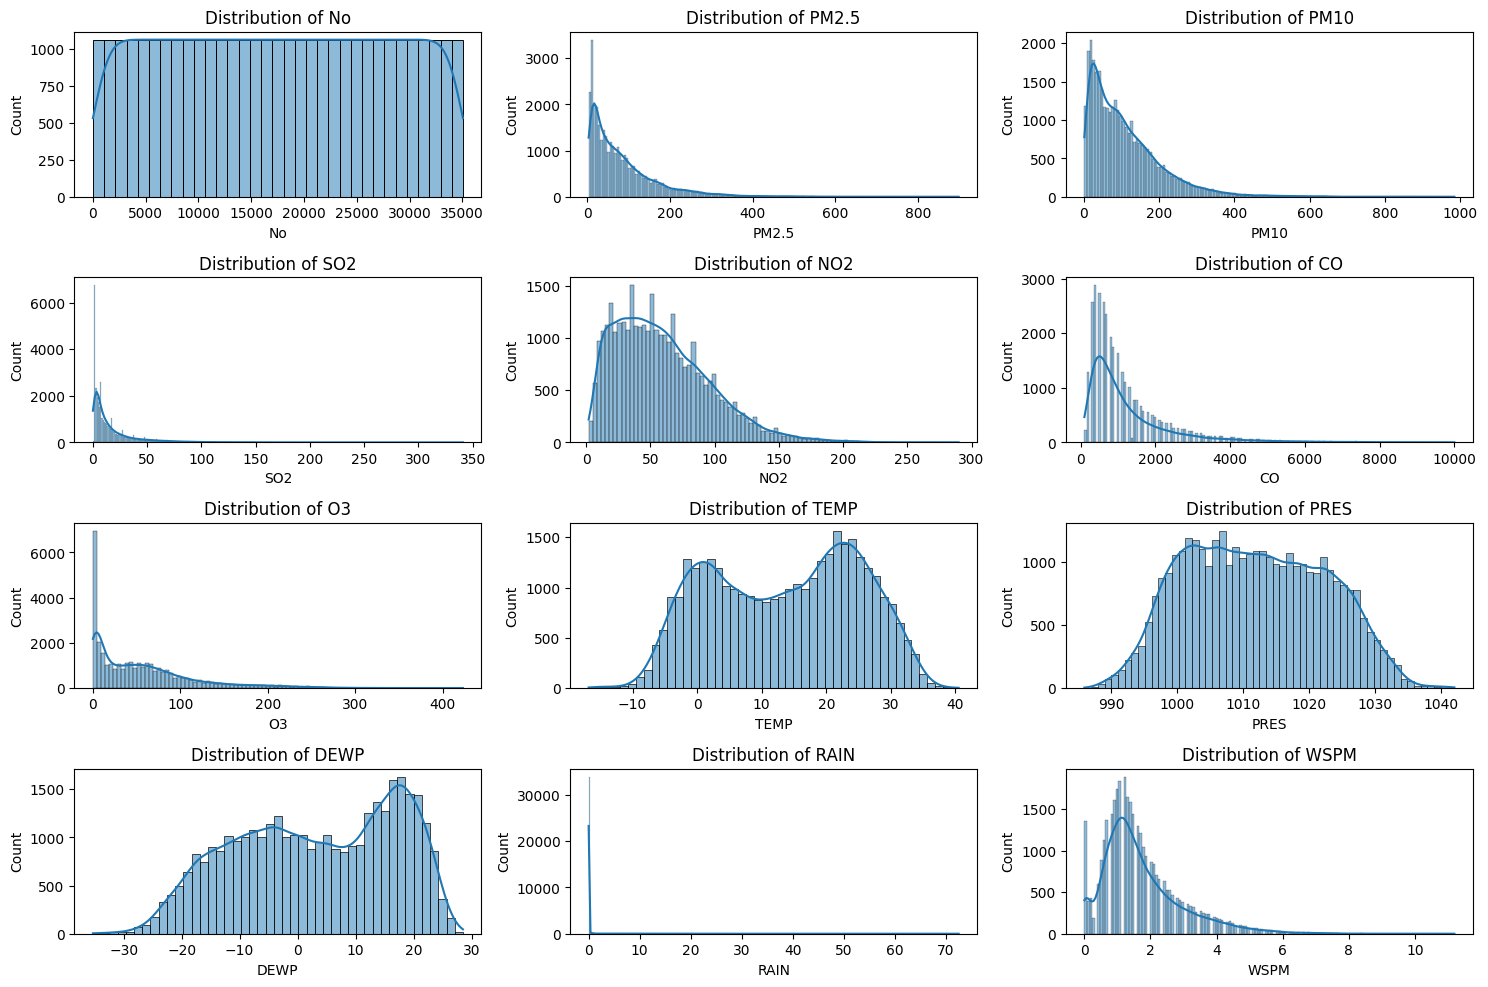

In [9]:
plt.figure(figsize=(15,12))
for i,col in enumerate(numeric_cols, 1):
    plt.subplot(len(numeric_cols)//3 +1 , 3, i)
    sns.histplot(data[col], kde=True)
    plt.title(f"Distribution of {col}")

plt.tight_layout()
plt.show()

In [10]:
len(data)

35064

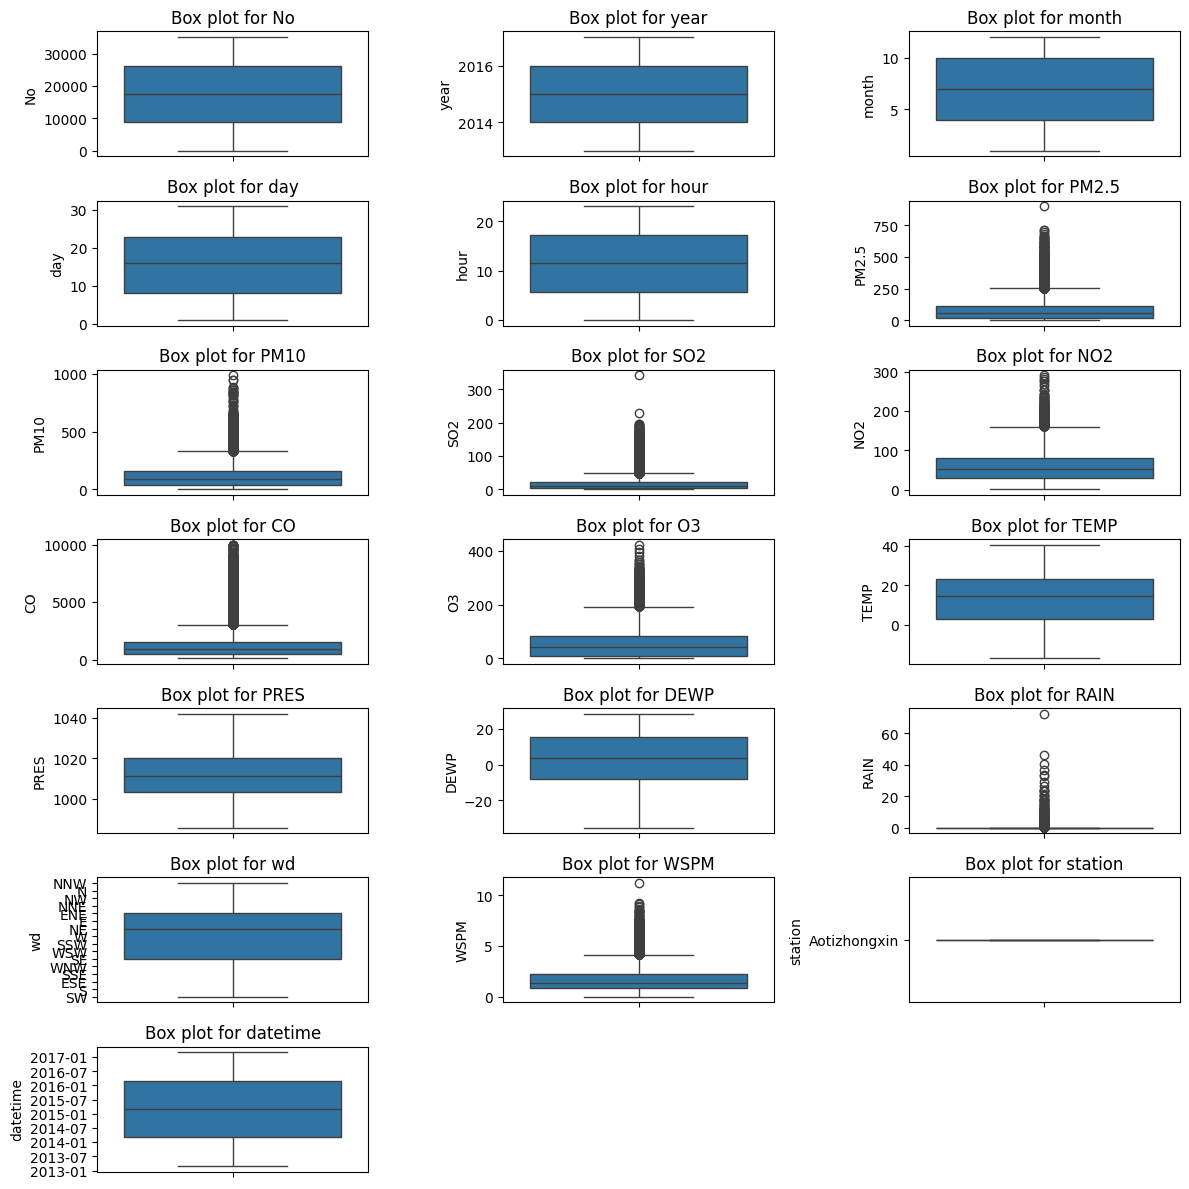

In [11]:
num_col = len(data.columns)
plt.figure(figsize=(12,12))
for i,col in enumerate(data, 1):
    plt.subplot(num_col // 3 + 1 , 3, i)
    sns.boxplot(data[col])
    plt.title(f"Box plot for {col}")

plt.tight_layout()
plt.show()

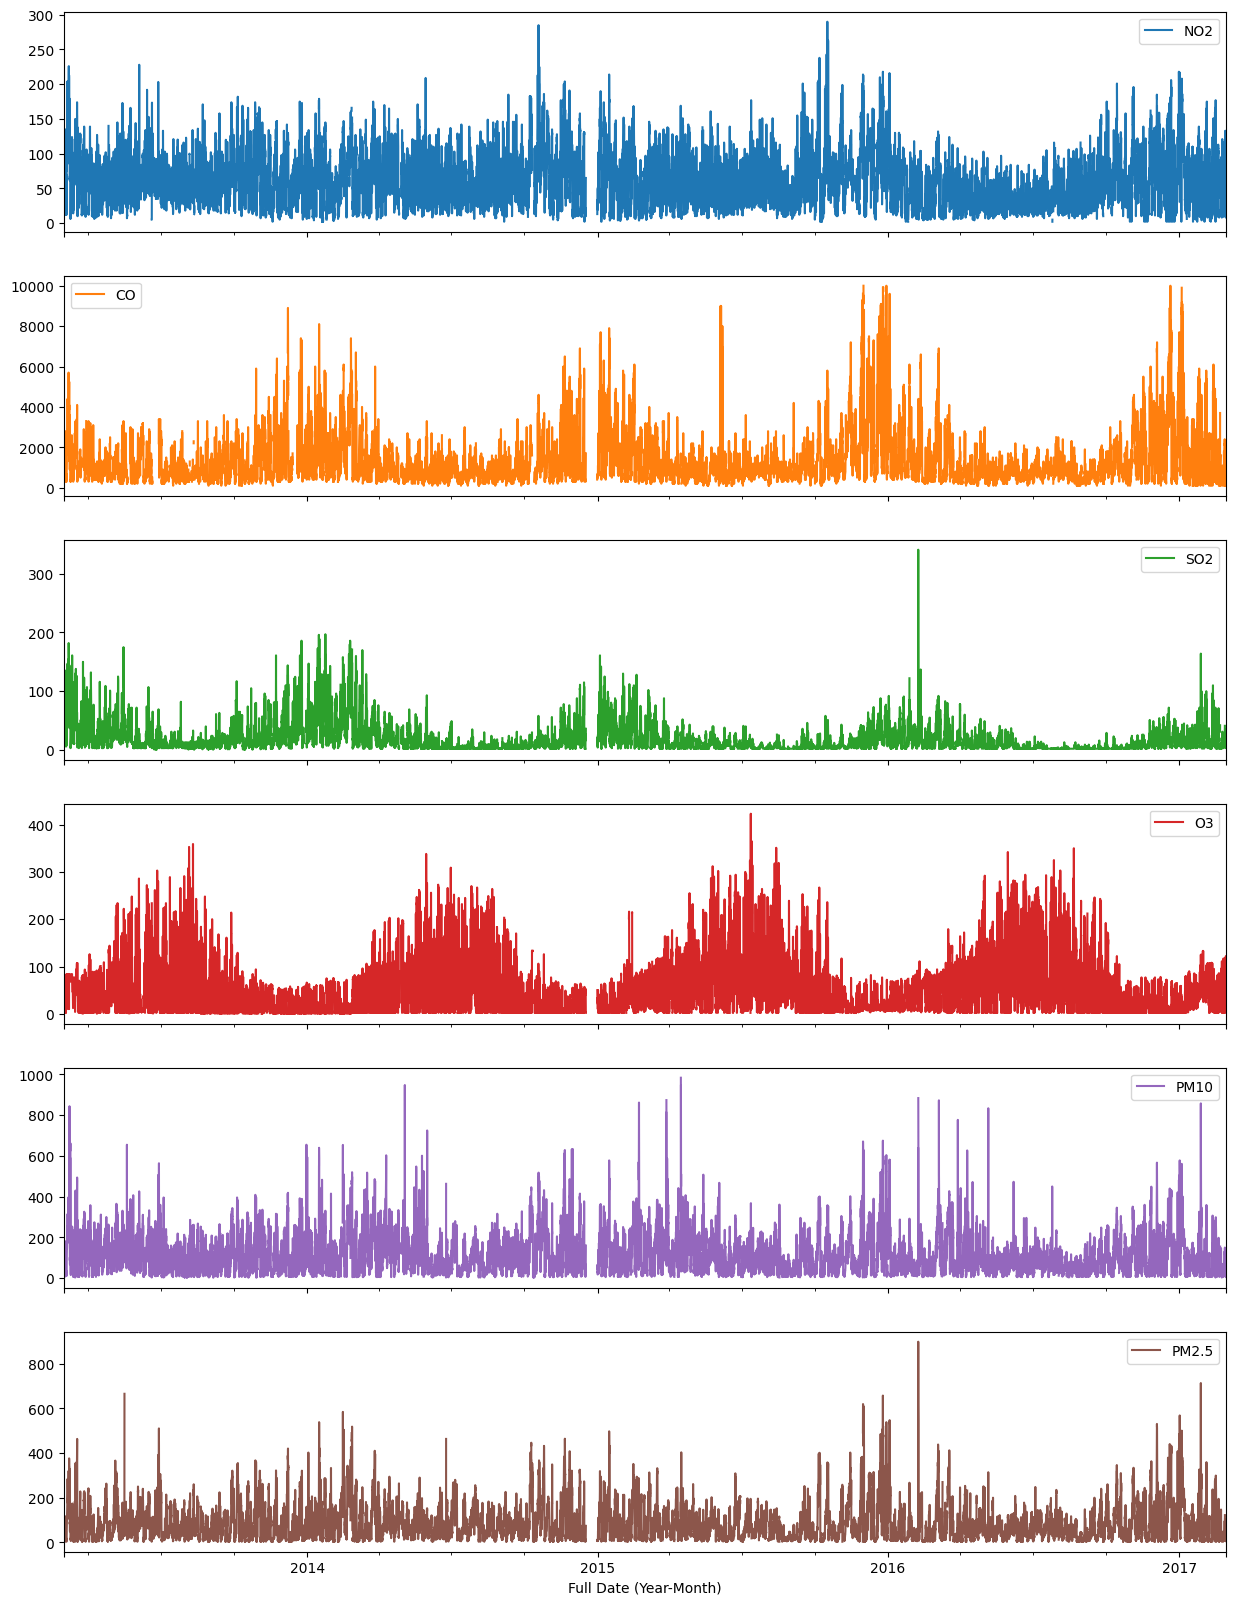

In [12]:
pollutants = ['NO2', 'CO', 'SO2', 'O3', 'PM10', 'PM2.5']
data.set_index('datetime')[pollutants].plot(subplots=True, figsize=(15, 20), sharex=True)
plt.xlabel('Full Date (Year-Month)')
plt.show()


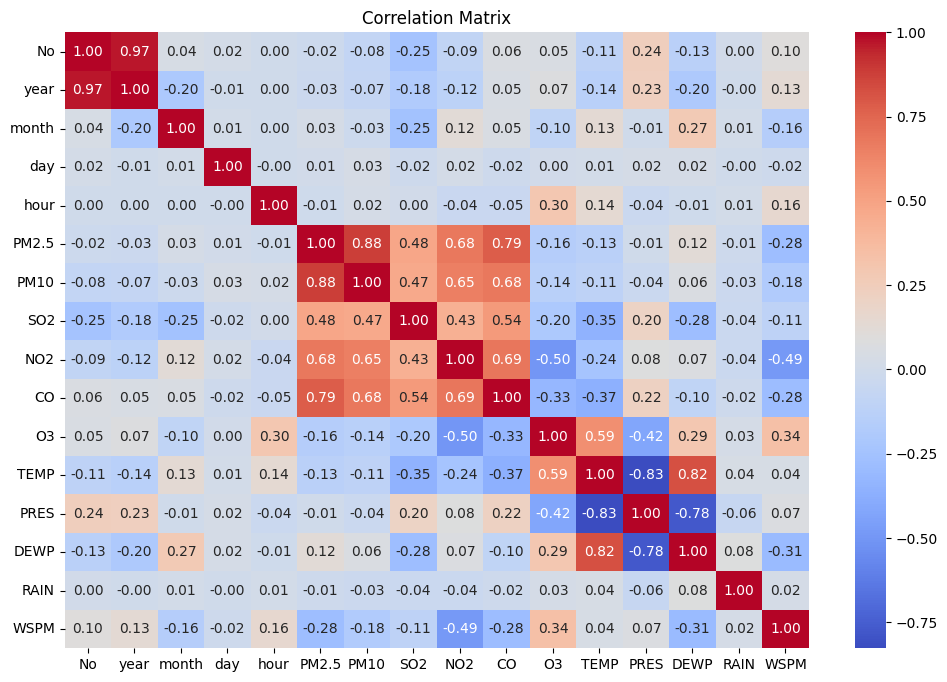

In [13]:
plt.figure(figsize=(12,8))
sns.heatmap(data.corr(numeric_only=True), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Matrix")
plt.show()